In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1
import requests
from scipy.stats import spearmanr

In [2]:
def get_race_results(Result):

    race = Result.results[["Abbreviation","Position"]]
    race.rename(columns={"Abbreviation":"Driver"},inplace=True)

    return race


In [3]:
season = 2026
race = 'Austria'

Result = fastf1.get_session(season, race, 'R')
Result.load()


result = get_race_results(Result)



req         WARNING 	DEFAULT CACHE ENABLED! (13.71 GB) /home/satyam/.cache/fastf1
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data

In [4]:
result.reset_index(inplace=True, drop=True)
result

,Driver,Position
0,RUS,1.0
1,VER,2.0
2,ANT,3.0
3,PIA,4.0
4,HAM,5.0
5,HAD,6.0
6,NOR,7.0
7,LEC,8.0
8,LAW,9.0
9,LIN,10.0


In [5]:
PRE = pd.read_csv("Data/PredictedData.csv")
PRE

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,Sector3_Rank,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart,Predicted_Result,Predicted_Pos
0,RUS,Mercedes,10.333333,5.166667,25.0,76.363,75.435,75.679,27.795167,37.480964,...,11,94.875238,5.089900,3,5.532107,244.0,21472.0,1.0,7.556232,1
1,HAM,Ferrari,7.333333,12.666667,24.0,78.172,76.631,76.381,35.381200,41.650393,...,18,107.606950,17.821612,20,14.096562,330.0,14850.0,10.0,7.791923,2
2,PIA,McLaren,5.333333,7.666667,5.0,76.566,75.483,75.893,30.272450,36.083208,...,12,96.200617,6.415279,5,7.181265,812.0,6728.0,14.0,7.877305,3
3,NOR,McLaren,12.333333,6.166667,5.0,78.172,75.426,75.925,32.221370,38.061300,...,8,99.562570,9.777233,15,11.391453,464.0,6728.0,16.0,7.929682,4
4,ANT,Mercedes,9.000000,17.000000,25.0,78.172,76.015,76.500,30.541731,36.241452,...,4,95.424924,5.639587,4,6.138507,732.0,38064.0,21.0,8.056350,5
5,LEC,Ferrari,11.000000,5.500000,24.0,76.883,75.799,75.922,33.514920,36.843536,...,7,99.361835,9.576497,16,12.758187,1650.0,12375.0,30.0,8.266901,6
6,VER,Red Bull Racing,13.333333,6.666667,18.5,77.047,76.321,76.434,28.601367,35.599091,...,1,91.193882,1.408544,1,0.000000,345.0,2967.0,30.0,8.267375,7
7,HAD,Red Bull Racing,6.333333,9.166667,18.5,78.172,76.674,76.684,30.813000,38.688500,...,19,100.118633,10.333296,13,9.867787,414.0,1794.0,48.0,8.709198,8
8,HUL,Audi,8.333333,4.166667,0.0,78.172,76.934,76.961,29.548333,37.388677,...,5,95.597172,5.811834,9,9.081811,18.0,0.0,81.0,9.506116,9
9,LAW,Racing Bulls,6.333333,7.166667,10.0,77.472,76.967,77.324,27.451800,38.549143,...,22,105.547193,15.761855,14,11.356507,280.0,840.0,96.0,9.866000,10


In [6]:
PRE.set_index("Driver", inplace=True)
result.set_index("Driver", inplace=True)

Final = result.copy()
Final["Predicted_Pos"] = PRE["Predicted_Pos"]

PRE.reset_index(inplace=True)
Final.reset_index(inplace=True)
result.reset_index(inplace=True)

Final

,Driver,Position,Predicted_Pos
0,RUS,1.0,1
1,VER,2.0,7
2,ANT,3.0,5
3,PIA,4.0,3
4,HAM,5.0,2
5,HAD,6.0,8
6,NOR,7.0,4
7,LEC,8.0,6
8,LAW,9.0,10
9,LIN,10.0,11


In [7]:
rho, p_value = spearmanr(Final['Position'],Final['Predicted_Pos'])
print(f"{rho}, {p_value}")

0.9265951439864484, 6.040358382311254e-10


In [8]:
podium = Final.loc[:,["Driver"]]
print("\n Final Standing")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank (Final): {rho:.2f}")


 Final Standing
🥇P1: RUS
🥈P2: VER
🥉P3: ANT
P4: PIA
P5: HAM
P6: HAD
P7: NOR
P8: LEC
P9: LAW
P10: LIN
P11: BOR
P12: HUL
Spearman Rank (Final): 0.93


In [9]:
PRE.set_index("Driver", inplace=True)
result.set_index("Driver", inplace=True)

df = PRE.copy()
df["Actual_Pos"] = result["Position"]


PRE.reset_index(inplace=True)
Final.reset_index(inplace=True,drop=True)

df.reset_index("Driver", inplace=True)

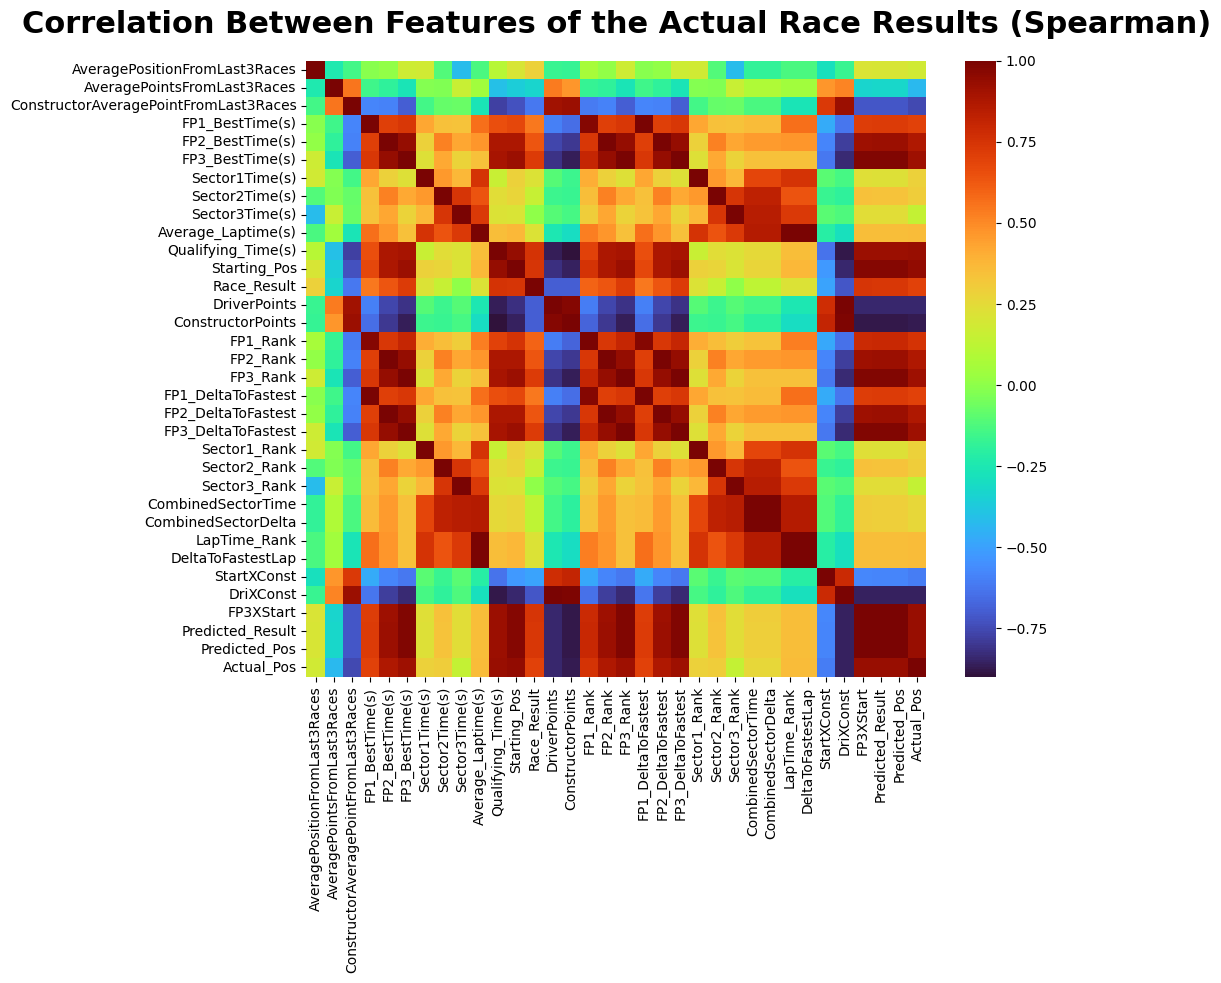

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=["Driver","Constructor"]).corr(method='spearman'), cmap='turbo')

plt.title('Correlation Between Features of the Actual Race Results (Spearman)', fontsize=22, fontweight='bold',pad=20)
plt.savefig('Plots/Result_Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


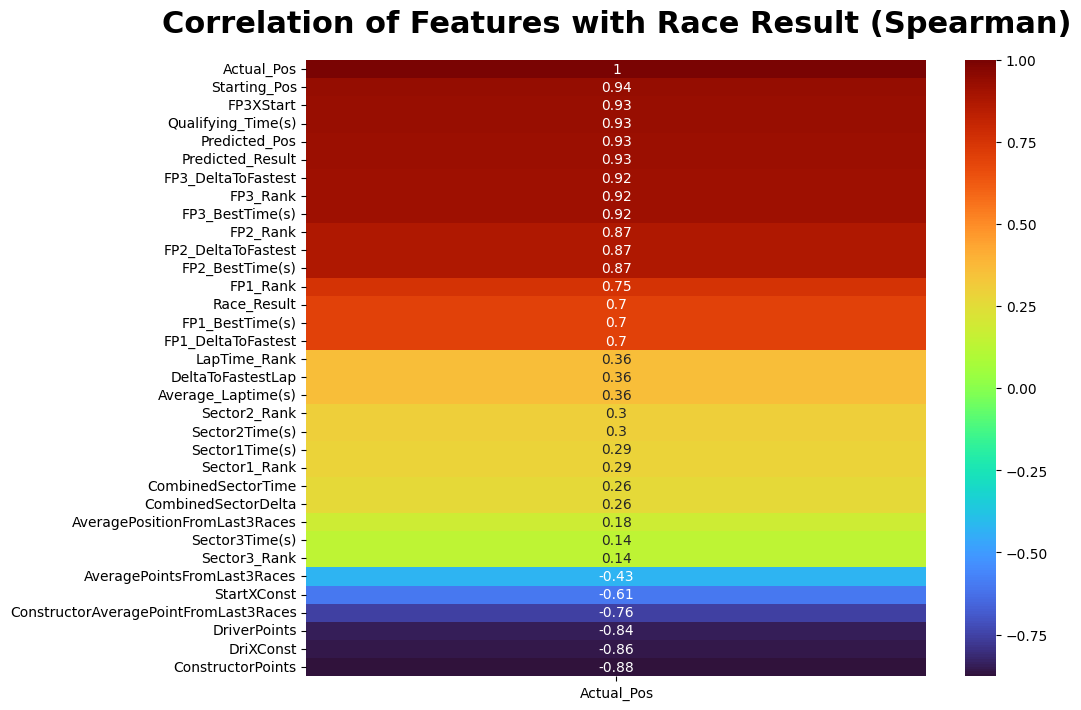

In [11]:
corr = df.drop(columns=["Driver","Constructor"]).corr(method='spearman')[['Actual_Pos']].sort_values(by='Actual_Pos', ascending=False)
plt.figure(figsize=(10,8))
plt.title('Correlation of Features with Race Result (Spearman)', fontsize=22, fontweight='bold',pad=20)
sns.heatmap(corr, annot=True, cmap='turbo')
plt.savefig('Plots/Result_Feature_RaceResult_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
Final["Position_Diff"] = Final["Predicted_Pos"] - Final["Position"]
Final

,Driver,Position,Predicted_Pos,Position_Diff
0,RUS,1.0,1,0.0
1,VER,2.0,7,5.0
2,ANT,3.0,5,2.0
3,PIA,4.0,3,-1.0
4,HAM,5.0,2,-3.0
5,HAD,6.0,8,2.0
6,NOR,7.0,4,-3.0
7,LEC,8.0,6,-2.0
8,LAW,9.0,10,1.0
9,LIN,10.0,11,1.0


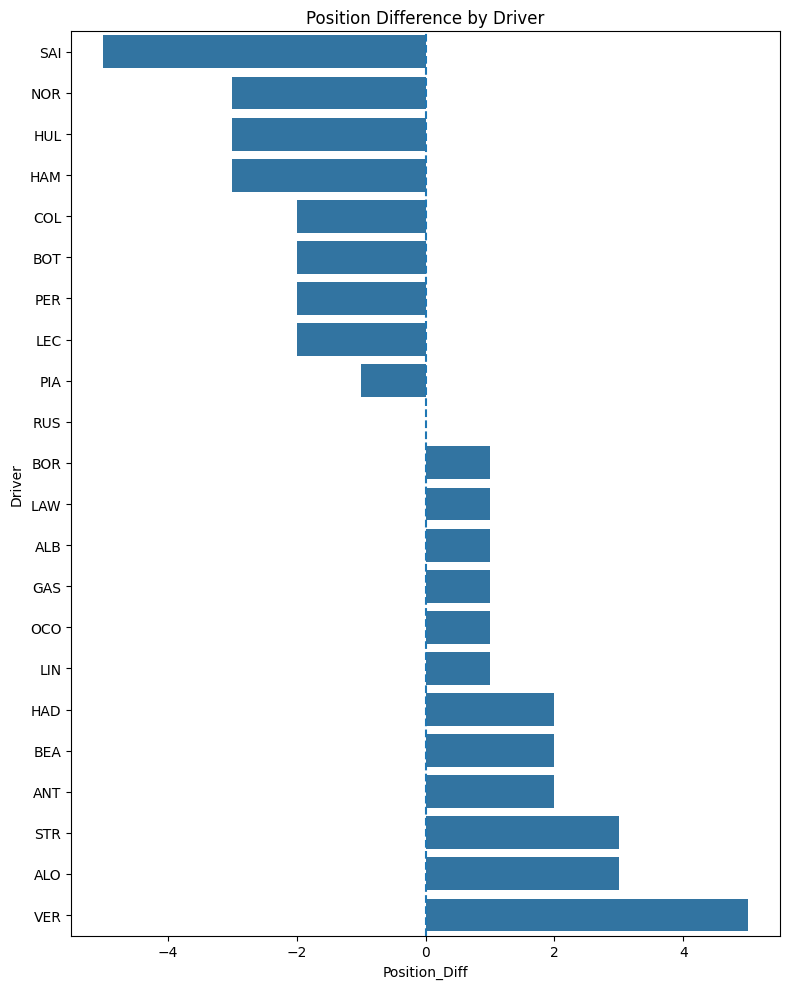

In [13]:
Final_sorted = Final.sort_values("Position_Diff")

plt.figure(figsize=(8,10))

sns.barplot(
    data=Final_sorted,
    y="Driver",
    x="Position_Diff"
)

plt.axvline(0, linestyle="--" )
plt.title("Position Difference by Driver")

plt.tight_layout()
plt.savefig('Plots/Position_Difference_by_Driver.png', dpi=300, bbox_inches='tight')

plt.show()